# Balanceo de Datos para Modelos de Clasificacion

**Curso III:** Modelado predictivo, automatizacion y proyectos inteligentes
**Bloque 1** - Aprendizaje supervisado

---

**PARTE A - Conceptos y tecnicas (datos sinteticos)**
1. El problema del desbalanceo y por que accuracy engana
2. Oversampling: SMOTE y variantes
3. Undersampling: RandomUnderSampler, Tomek Links
4. class_weight: ajuste interno de modelos
5. Threshold tuning: ajustar punto de corte segun costo del error
6. Matrices de costo: FN vs FP

**PARTE B - Caso real: deteccion de fraude con tarjeta de credito**
- Dataset: Credit Card Fraud Detection (Kaggle / ULB)
- Subconjunto: ~32,363 transacciones, 219 fraudes (~0.68%)
- Comparacion justa: mismo modelo (LR), distinta estrategia de balanceo

INSTALACION DE DEPENDENCIAS

In [1]:
# Ejecutar esta celda primero en Google Colab
# !pip install -q imbalanced-learn kagglehub

IMPORTS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, SVMSMOTE
from imblearn.under_sampling import (
    RandomUnderSampler,
    TomekLinks,
    NearMiss,
    EditedNearestNeighbours,
)
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PARTE A: CONCEPTOS Y TECNICAS (DATOS SINTETICOS)

SECCION 1: EL PROBLEMA DEL DESBALANCEO

En problemas reales de clasificacion (fraude, diagnostico medico, fallas
industriales, churn), es muy comun que una clase sea mucho menos frecuente
que la otra. Un dataset se considera desbalanceado cuando la proporcion
entre clases es significativamente desigual. Ejemplos:

- Fraude bancario: ~0.1% de transacciones son fraudulentas
- Cancer: ~2-5% de biopsias son malignas
- Fallas de equipos: ~1% de registros corresponden a fallas

El problema fundamental: un modelo puede alcanzar accuracy alto simplemente
prediciendo siempre la clase mayoritaria, sin haber aprendido nada util.

### 1.1 Crear un dataset sintetico desbalanceado (95:5)

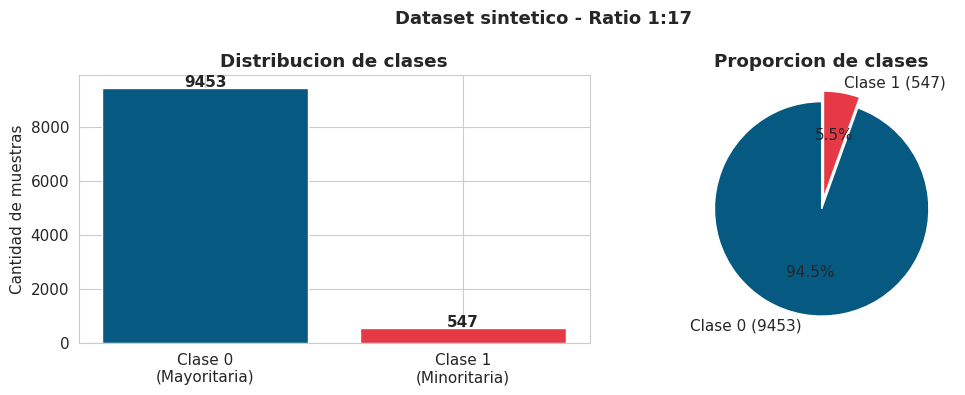

In [3]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=3,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    random_state=RANDOM_STATE,
)

unique, counts = np.unique(y, return_counts=True)
ratio = counts.min() / counts.max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#065A82", "#E63946"]
axes[0].bar(["Clase 0\n(Mayoritaria)", "Clase 1\n(Minoritaria)"], counts, color=colors)
axes[0].set_title("Distribucion de clases", fontweight="bold")
axes[0].set_ylabel("Cantidad de muestras")
for i, cnt in enumerate(counts):
    axes[0].text(i, cnt + 50, f"{cnt}", ha="center", fontweight="bold")

axes[1].pie(
    counts,
    labels=[f"Clase 0 ({counts[0]})", f"Clase 1 ({counts[1]})"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.1),
)
axes[1].set_title("Proporcion de clases", fontweight="bold")

plt.suptitle(f"Dataset sintetico - Ratio 1:{int(1/ratio)}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Por que accuracy engana
Entrenamos un modelo sin correccion y lo comparamos con un "modelo ingenuo"
que siempre predice la clase mayoritaria.

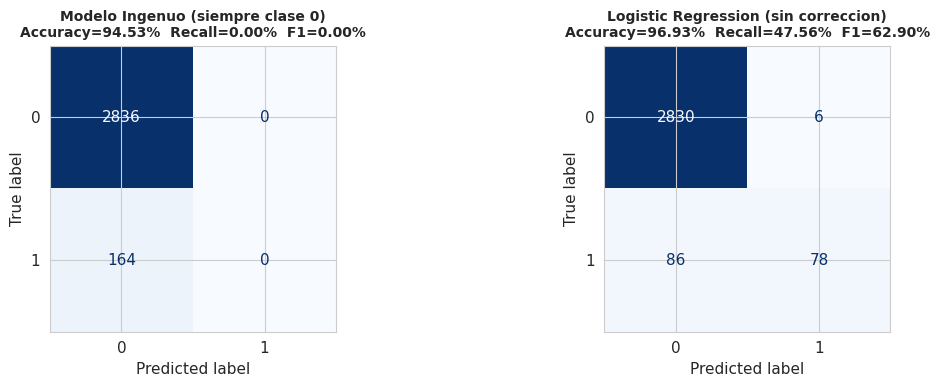

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Modelo baseline
lr_baseline = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_baseline.fit(X_train_sc, y_train)
y_pred_baseline = lr_baseline.predict(X_test_sc)

# Modelo ingenuo: siempre predice clase 0
y_pred_naive = np.zeros_like(y_test)

# Comparacion visual con matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(
    f"Modelo Ingenuo (siempre clase 0)\n"
    f"Accuracy={accuracy_score(y_test, y_pred_naive):.2%}  "
    f"Recall={recall_score(y_test, y_pred_naive):.2%}  "
    f"F1={f1_score(y_test, y_pred_naive):.2%}",
    fontweight="bold", fontsize=10,
)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title(
    f"Logistic Regression (sin correccion)\n"
    f"Accuracy={accuracy_score(y_test, y_pred_baseline):.2%}  "
    f"Recall={recall_score(y_test, y_pred_baseline):.2%}  "
    f"F1={f1_score(y_test, y_pred_baseline):.2%}",
    fontweight="bold", fontsize=10,
)

plt.tight_layout()
plt.show()

### 1.3 Leccion clave
El modelo ingenuo tiene ~95% de accuracy sin haber aprendido nada.
Metricas adecuadas para desbalanceo:
- Recall (Sensibilidad): de los positivos reales, cuantos detecto?
- Precision: de los que marco como positivos, cuantos realmente lo son?
- F1-Score: media armonica de precision y recall
- AUC-PR: area bajo la curva Precision-Recall

SECCION 2: OVERSAMPLING - SMOTE Y VARIANTES

SMOTE (Synthetic Minority Over-sampling Technique, Chawla et al. 2002)
genera muestras sinteticas de la clase minoritaria interpolando entre
vecinos cercanos, en lugar de duplicar muestras (lo cual causa overfitting).

Algoritmo:
1. Seleccionar una muestra de la clase minoritaria
2. Encontrar sus k vecinos mas cercanos (default k=5)
3. Elegir aleatoriamente uno de esos vecinos
4. Generar punto sintetico: x_new = x_i + rand(0,1) * (x_nn - x_i)
5. Repetir hasta alcanzar el balance deseado

IMPORTANTE: SMOTE solo se aplica al conjunto de entrenamiento, NUNCA al
de test/validacion. Aplicarlo antes del split causa data leakage.

### 2.1 Aplicar SMOTE y variantes

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

bsmote = BorderlineSMOTE(random_state=RANDOM_STATE)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train, y_train)

adasyn = ADASYN(random_state=RANDOM_STATE)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

svmsmote = SVMSMOTE(random_state=RANDOM_STATE)
X_svmsmote, y_svmsmote = svmsmote.fit_resample(X_train, y_train)

variantes_over = {
    "SMOTE": (X_smote, y_smote),
    "Borderline-SMOTE": (X_bsmote, y_bsmote),
    "ADASYN": (X_adasyn, y_adasyn),
    "SVM-SMOTE": (X_svmsmote, y_svmsmote),
}

# Tabla comparativa
u_orig, c_orig = np.unique(y_train, return_counts=True)
rows = [{"Tecnica": "Original", "Clase 0": c_orig[0], "Clase 1": c_orig[1], "Total": sum(c_orig)}]
for name, (_, y_res) in variantes_over.items():
    u, c = np.unique(y_res, return_counts=True)
    rows.append({"Tecnica": name, "Clase 0": c[0], "Clase 1": c[1], "Total": sum(c)})

pd.DataFrame(rows).set_index("Tecnica")

,Clase 0,Clase 1,Total
Tecnica,,,
Original,6617,383,7000
SMOTE,6617,6617,13234
Borderline-SMOTE,6617,6617,13234
ADASYN,6617,6665,13282
SVM-SMOTE,6617,6617,13234


### 2.2 Rendimiento comparativo

In [6]:
results_over = {}
for name, (X_res, y_res) in variantes_over.items():
    sc = StandardScaler()
    X_res_sc = sc.fit_transform(X_res)
    X_t = sc.transform(X_test)
    model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    model.fit(X_res_sc, y_res)
    y_pred = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    results_over[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-PR": average_precision_score(y_test, y_proba),
    }

pd.DataFrame(results_over).T.round(4)

,Precision,Recall,F1,AUC-PR
SMOTE,0.2037,0.7317,0.3187,0.6272
Borderline-SMOTE,0.1940,0.7439,0.3077,0.6179
ADASYN,0.1617,0.7622,0.2668,0.6181
SVM-SMOTE,0.2177,0.7195,0.3343,0.6186


### 2.3 Visualizacion en 2D del efecto de SMOTE

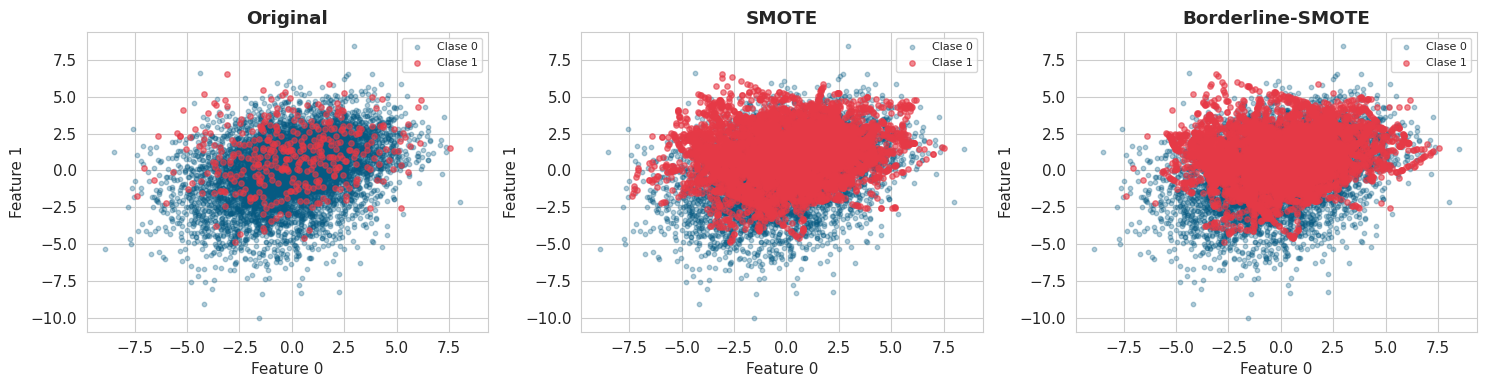

In [7]:
f1_idx, f2_idx = 0, 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, X_data, y_data) in zip(axes, [
    ("Original", X_train, y_train),
    ("SMOTE", X_smote, y_smote),
    ("Borderline-SMOTE", X_bsmote, y_bsmote),
]):
    ax.scatter(X_data[y_data == 0, f1_idx], X_data[y_data == 0, f2_idx],
               alpha=0.3, s=10, c="#065A82", label="Clase 0")
    ax.scatter(X_data[y_data == 1, f1_idx], X_data[y_data == 1, f2_idx],
               alpha=0.6, s=15, c="#E63946", label="Clase 1")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlabel(f"Feature {f1_idx}")
    ax.set_ylabel(f"Feature {f2_idx}")

plt.tight_layout()
plt.show()

SECCION 3: UNDERSAMPLING

Reduce la cantidad de muestras de la clase mayoritaria. Es mas rapido que
oversampling pero tiene el riesgo de perder informacion valiosa.

Tecnicas principales:
- RandomUnderSampler: elimina muestras aleatoriamente
- Tomek Links: elimina pares de clases opuestas que son vecinos cercanos
  (limpia la frontera de decision)
- NearMiss: selecciona muestras de la mayoritaria cercanas a la minoritaria
- EditedNN (ENN): elimina muestras cuya clase no coincide con sus vecinos

Tecnicas combinadas:
- SMOTE-Tomek: aplica SMOTE + elimina Tomek Links
- SMOTE-ENN: aplica SMOTE + limpia con EditedNearestNeighbours

### 3.1 Aplicar tecnicas de undersampling

In [8]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train, y_train)

nearmiss = NearMiss(version=1)
X_nm, y_nm = nearmiss.fit_resample(X_train, y_train)

enn = EditedNearestNeighbours()
X_enn, y_enn = enn.fit_resample(X_train, y_train)

smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_st, y_st = smote_tomek.fit_resample(X_train, y_train)

smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_se, y_se = smote_enn.fit_resample(X_train, y_train)

under_tecnicas = {
    "Original": (X_train, y_train),
    "RandomUnderSampler": (X_rus, y_rus),
    "TomekLinks": (X_tomek, y_tomek),
    "NearMiss-1": (X_nm, y_nm),
    "EditedNN": (X_enn, y_enn),
    "SMOTE-Tomek": (X_st, y_st),
    "SMOTE-ENN": (X_se, y_se),
}

total_original = len(y_train)
rows_u = []
for name, (_, y_res) in under_tecnicas.items():
    u, c = np.unique(y_res, return_counts=True)
    rows_u.append({
        "Tecnica": name,
        "Clase 0": c[0],
        "Clase 1": c[1] if len(c) > 1 else 0,
        "Total": len(y_res),
        "Reduccion (%)": round((1 - len(y_res) / total_original) * 100, 1),
    })

pd.DataFrame(rows_u).set_index("Tecnica")

,Clase 0,Clase 1,Total,Reduccion (%)
Tecnica,,,,
Original,6617,383,7000,0.0
RandomUnderSampler,383,383,766,89.1
TomekLinks,6595,383,6978,0.3
NearMiss-1,383,383,766,89.1
EditedNN,6426,383,6809,2.7
SMOTE-Tomek,6617,6617,13234,-89.1
SMOTE-ENN,6021,6612,12633,-80.5


### 3.2 Rendimiento comparativo

In [9]:
results_under = {}
for name, (X_res, y_res) in under_tecnicas.items():
    if name == "Original":
        continue
    sc = StandardScaler()
    X_res_sc = sc.fit_transform(X_res)
    X_t = sc.transform(X_test)
    model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    model.fit(X_res_sc, y_res)
    y_pred = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    results_under[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-PR": average_precision_score(y_test, y_proba),
    }

pd.DataFrame(results_under).T.round(4)

,Precision,Recall,F1,AUC-PR
RandomUnderSampler,0.1713,0.7439,0.2785,0.5963
TomekLinks,0.9286,0.4756,0.6290,0.6379
NearMiss-1,0.1232,0.7317,0.2109,0.2623
EditedNN,0.9070,0.4756,0.6240,0.6384
SMOTE-Tomek,0.2037,0.7317,0.3187,0.6272
SMOTE-ENN,0.1851,0.7439,0.2965,0.6258


### 3.3 Visualizacion: efecto de Tomek Links en la frontera

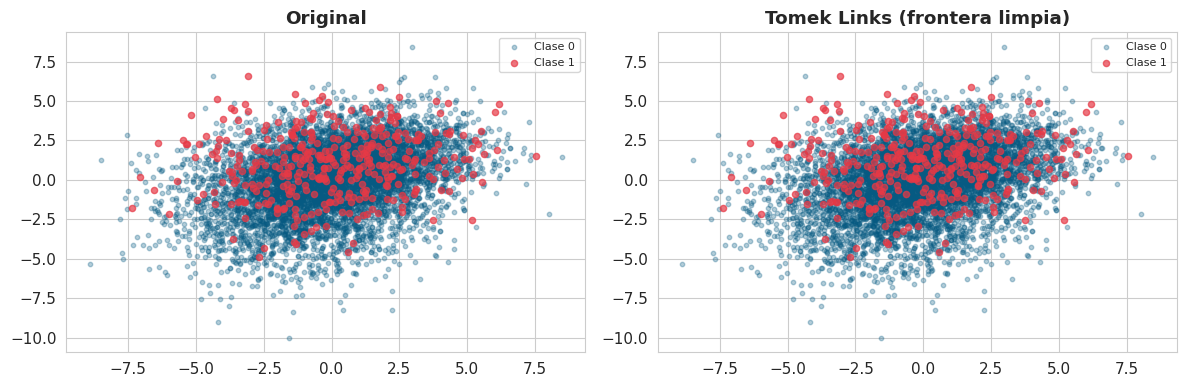

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, X_data, y_data) in zip(axes, [
    ("Original", X_train, y_train),
    ("Tomek Links (frontera limpia)", X_tomek, y_tomek),
]):
    ax.scatter(X_data[y_data == 0, f1_idx], X_data[y_data == 0, f2_idx],
               alpha=0.3, s=10, c="#065A82", label="Clase 0")
    ax.scatter(X_data[y_data == 1, f1_idx], X_data[y_data == 1, f2_idx],
               alpha=0.7, s=20, c="#E63946", label="Clase 1")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

SECCION 4: CLASS_WEIGHT - AJUSTE INTERNO DE MODELOS

Muchos algoritmos de scikit-learn soportan class_weight, que asigna pesos
diferentes a cada clase durante el entrenamiento.

Con class_weight='balanced', se calcula automaticamente:
w_j = n_samples / (n_classes * n_samples_j)

Esto hace que los errores en la clase minoritaria pesen mas en la funcion
de costo, forzando al modelo a prestarle mas atencion.

Modelos compatibles: LogisticRegression, SVC, DecisionTree, RandomForest,
GradientBoosting (via sample_weight), SGDClassifier.

### 4.1 Calculo de pesos

In [11]:
n_samples = len(y_train)
n_classes = len(np.unique(y_train))
u_tr, c_tr = np.unique(y_train, return_counts=True)

peso_clase_0 = n_samples / (n_classes * c_tr[0])
peso_clase_1 = n_samples / (n_classes * c_tr[1])

pd.DataFrame({
    "Clase": [0, 1],
    "Muestras": c_tr,
    "Peso (balanced)": [round(peso_clase_0, 4), round(peso_clase_1, 4)],
    "Factor vs clase 0": [1.0, round(peso_clase_1 / peso_clase_0, 1)],
})

,Clase,Muestras,Peso (balanced),Factor vs clase 0
0,0,6617,0.5289,1.0
1,1,383,9.1384,17.3


### 4.2 Comparar modelos con y sin class_weight

In [12]:
modelos = {
    "LogisticRegression": (
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    ),
    "RandomForest": (
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    ),
    "DecisionTree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    ),
    "SVM": (
        SVC(random_state=RANDOM_STATE, probability=True),
        SVC(class_weight="balanced", random_state=RANDOM_STATE, probability=True),
    ),
}

results_cw = []
for name, (m_base, m_bal) in modelos.items():
    for label, model in [("Sin peso", m_base), ("Balanced", m_bal)]:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
        results_cw.append({
            "Modelo": name, "Config": label,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "AUC-PR": average_precision_score(y_test, y_proba),
        })

df_cw = pd.DataFrame(results_cw)
df_cw.round(4)

,Modelo,Config,Accuracy,Precision,Recall,F1,AUC-PR
0,LogisticRegression,Sin peso,0.9693,0.9286,0.4756,0.6290,0.6373
1,LogisticRegression,Balanced,0.8057,0.1840,0.7439,0.2950,0.6167
2,RandomForest,Sin peso,0.9627,0.9815,0.3232,0.4862,0.7565
3,RandomForest,Balanced,0.9603,1.0000,0.2744,0.4306,0.8108
4,DecisionTree,Sin peso,0.9410,0.4629,0.4939,0.4779,0.2563
5,DecisionTree,Balanced,0.9470,0.5177,0.4451,0.4787,0.2608
6,SVM,Sin peso,0.9807,0.9818,0.6585,0.7883,0.8615
7,SVM,Balanced,0.9723,0.7189,0.8110,0.7622,0.8380


### 4.3 Visualizacion del impacto

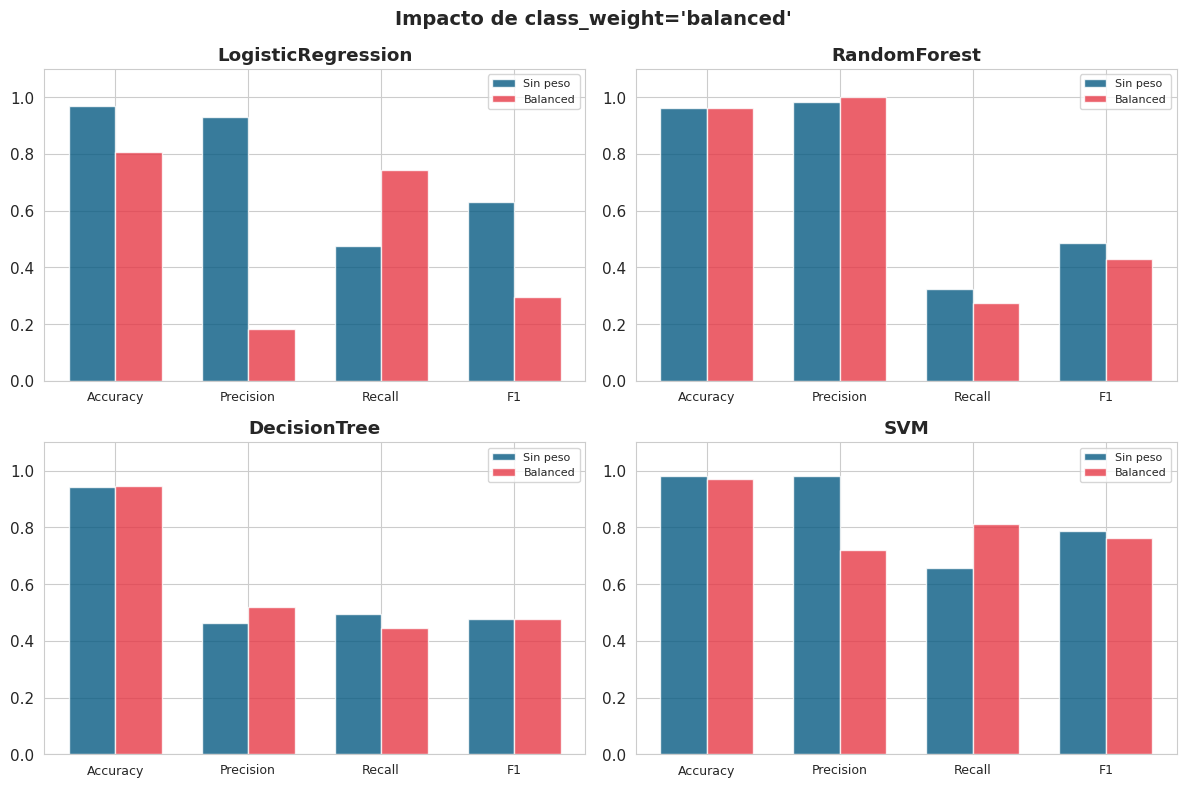

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, name in enumerate(modelos.keys()):
    ax = axes[idx // 2, idx % 2]
    df_m = df_cw[df_cw["Modelo"] == name]
    metricas = ["Accuracy", "Precision", "Recall", "F1"]
    x = np.arange(len(metricas))
    w = 0.35
    vals_sin = df_m[df_m["Config"] == "Sin peso"][metricas].values[0]
    vals_con = df_m[df_m["Config"] == "Balanced"][metricas].values[0]
    ax.bar(x - w/2, vals_sin, w, label="Sin peso", color="#065A82", alpha=0.8)
    ax.bar(x + w/2, vals_con, w, label="Balanced", color="#E63946", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metricas, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(name, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Impacto de class_weight='balanced'", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

SECCION 5: THRESHOLD TUNING

Los modelos probabilisticos producen una probabilidad y aplican un umbral
(threshold) para decidir la clase. Por defecto es 0.5, pero casi nunca
es optimo con datos desbalanceados.

Ajustar el threshold controla el trade-off precision/recall:
- Bajar (ej: 0.3): mas sensible, mayor recall, pero mas FP
- Subir (ej: 0.7): mas conservador, mayor precision, pero mas FN

### 5.1 Distribucion de probabilidades predichas

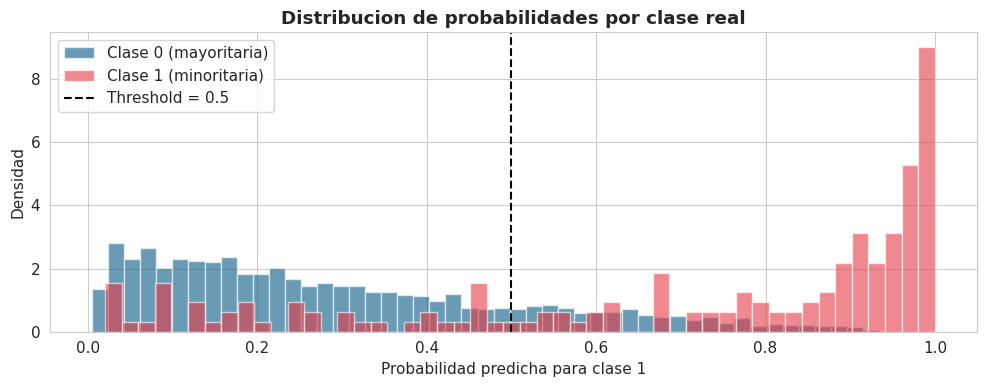

In [14]:
lr_balanced = LogisticRegression(
    class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000
)
lr_balanced.fit(X_train_sc, y_train)
y_proba_bal = lr_balanced.predict_proba(X_test_sc)[:, 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_proba_bal[y_test == 0], bins=50, alpha=0.6, color="#065A82",
        label="Clase 0 (mayoritaria)", density=True)
ax.hist(y_proba_bal[y_test == 1], bins=50, alpha=0.6, color="#E63946",
        label="Clase 1 (minoritaria)", density=True)
ax.axvline(x=0.5, color="black", linestyle="--", label="Threshold = 0.5")
ax.set_xlabel("Probabilidad predicha para clase 1")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de probabilidades por clase real", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Precision, Recall y F1 segun threshold

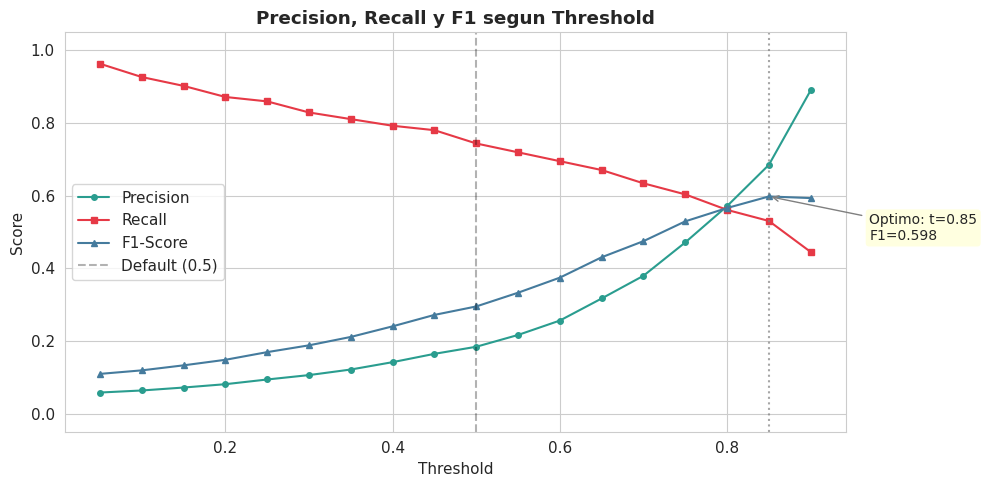

In [15]:
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_t = []
for t in thresholds:
    y_pred_t = (y_proba_bal >= t).astype(int)
    metrics_t.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t, zero_division=0),
    })

df_t = pd.DataFrame(metrics_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t["Threshold"], df_t["Precision"], "o-", color="#2A9D8F", label="Precision", ms=4)
ax.plot(df_t["Threshold"], df_t["Recall"], "s-", color="#E63946", label="Recall", ms=4)
ax.plot(df_t["Threshold"], df_t["F1"], "^-", color="#457B9D", label="F1-Score", ms=4)

best_idx = df_t["F1"].idxmax()
best_t = df_t.loc[best_idx, "Threshold"]
best_f1 = df_t.loc[best_idx, "F1"]
ax.axvline(x=best_t, color="gray", linestyle=":", alpha=0.7)
ax.annotate(f"Optimo: t={best_t:.2f}\nF1={best_f1:.3f}", xy=(best_t, best_f1),
            xytext=(best_t + 0.12, best_f1 - 0.12),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.3, label="Default (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall y F1 segun Threshold", fontweight="bold")
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### 5.3 Curva Precision-Recall

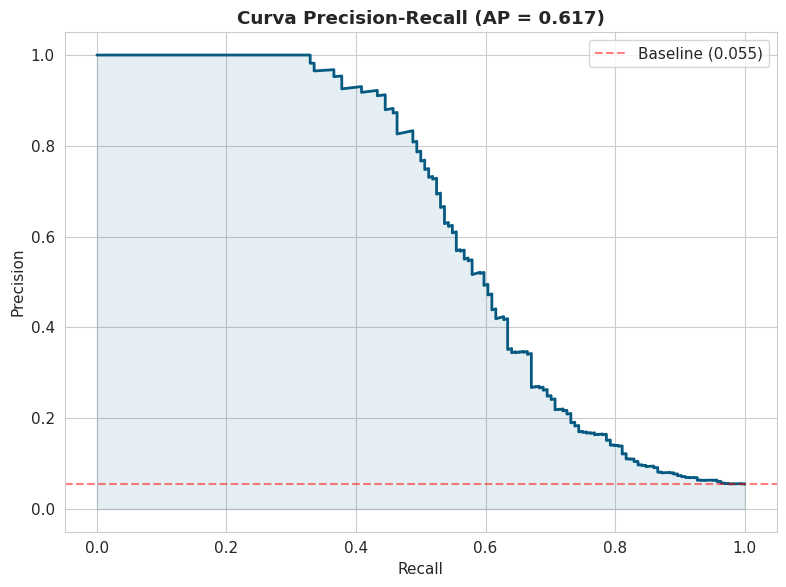

In [16]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_bal)
ap = average_precision_score(y_test, y_proba_bal)
baseline_pr = y_test.sum() / len(y_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_curve, prec_curve, color="#065A82", lw=2)
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color="#065A82")
ax.axhline(y=baseline_pr, color="red", linestyle="--", alpha=0.5,
           label=f"Baseline ({baseline_pr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Curva Precision-Recall (AP = {ap:.3f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

SECCION 6: MATRICES DE COSTO - FN vs FP

En la vida real, no todos los errores cuestan lo mismo:

               Pred: Negativo      Pred: Positivo
Real: Negativo      TN (0)            FP (costo C_FP)
Real: Positivo      FN (costo C_FN)   TP (0 o beneficio)

Costo_total = n_FP * C_FP + n_FN * C_FN

El threshold optimo depende de estos costos, no solo de F1.

### 6.1 Analisis de costo por threshold (Escenario: Fraude bancario)

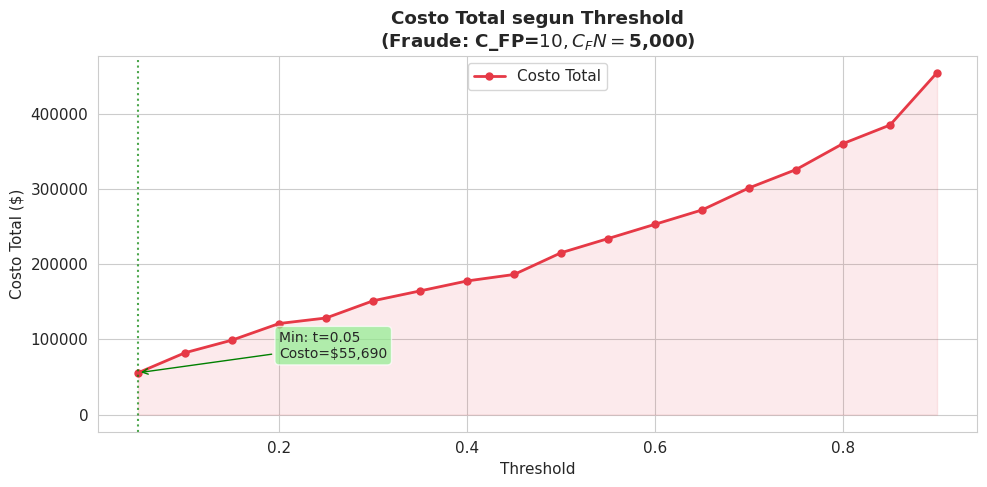

In [17]:
C_FP = 10     # Costo de investigar transaccion legitima
C_FN = 5000   # Costo de no detectar un fraude

costos = []
for t in thresholds:
    y_pred_t = (y_proba_bal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    costos.append({
        "Threshold": round(t, 2), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Costo_FP": fp * C_FP, "Costo_FN": fn * C_FN,
        "Costo_Total": fp * C_FP + fn * C_FN,
    })

df_costos = pd.DataFrame(costos)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_costos["Threshold"], df_costos["Costo_Total"],
        "o-", color="#E63946", lw=2, ms=5, label="Costo Total")
ax.fill_between(df_costos["Threshold"], df_costos["Costo_Total"], alpha=0.1, color="#E63946")

min_idx = df_costos["Costo_Total"].idxmin()
min_t = df_costos.loc[min_idx, "Threshold"]
min_costo = df_costos.loc[min_idx, "Costo_Total"]
ax.axvline(x=min_t, color="green", linestyle=":", alpha=0.7)
ax.annotate(f"Min: t={min_t:.2f}\nCosto=${min_costo:,.0f}", xy=(min_t, min_costo),
            xytext=(min_t + 0.15, min_costo + 20000),
            arrowprops=dict(arrowstyle="->", color="green"), fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

ax.set_xlabel("Threshold")
ax.set_ylabel("Costo Total ($)")
ax.set_title("Costo Total segun Threshold\n(Fraude: C_FP=$10, C_FN=$5,000)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Threshold optimo por escenario

In [18]:
escenarios = {
    "Fraude bancario":    {"C_FP": 10,  "C_FN": 5000},
    "Diagnostico medico": {"C_FP": 500, "C_FN": 50000},
    "Spam email":         {"C_FP": 50,  "C_FN": 1},
    "Falla industrial":   {"C_FP": 200, "C_FN": 100000},
}

rows_esc = []
for nombre, esc in escenarios.items():
    mejor_costo = np.inf
    mejor_t = 0.5
    for t in thresholds:
        y_pred_t = (y_proba_bal >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        costo = fp * esc["C_FP"] + fn * esc["C_FN"]
        if costo < mejor_costo:
            mejor_costo = costo
            mejor_t = t
    rows_esc.append({
        "Escenario": nombre,
        "C_FP ($)": esc["C_FP"],
        "C_FN ($)": esc["C_FN"],
        "Ratio C_FN/C_FP": esc["C_FN"] // esc["C_FP"],
        "Threshold optimo": mejor_t,
        "Costo minimo ($)": mejor_costo,
    })

df_esc = pd.DataFrame(rows_esc).set_index("Escenario")
df_esc

# Observacion: cuando C_FN >> C_FP (fraude, diagnostico, fallas), el threshold
# optimo baja para no perder positivos reales. Cuando C_FP >> C_FN (spam),
# el threshold sube para evitar molestar al usuario.

,C_FP ($),C_FN ($),Ratio C_FN/C_FP,Threshold optimo,Costo minimo ($)
Escenario,,,,,
Fraude bancario,10,5000,500,0.05,55690
Diagnostico medico,500,50000,100,0.05,1584500
Spam email,50,1,0,0.90,541
Falla industrial,200,100000,500,0.05,1113800


PARTE B: CASO REAL - DETECCION DE FRAUDE CON TARJETA DE CREDITO

SECCION 7: CARGAR Y SUBMUESTREAR EL DATASET

Dataset: Credit Card Fraud Detection (Kaggle / ULB)
Original: 284,807 transacciones, 492 fraudes (0.172%).
Features V1-V28 son componentes PCA (anonimizadas).
'Time' y 'Amount' son las unicas features originales.

Para hacer el notebook mas eficiente computacionalmente, tomamos un
subconjunto representativo: ~32,144 transacciones legitimas y 219 fraudes
(~0.68%), manteniendo un desbalanceo realista y severo.

In [35]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df_full = pd.read_csv(f"{path}/creditcard.csv")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [36]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 7.1 Submuestreo estratificado
Separamos fraudes y legitimas, tomamos un subconjunto de cada una

In [20]:
df_fraude = df_full[df_full["Class"] == 1].sample(n=492, random_state=RANDOM_STATE)
df_legit = df_full[df_full["Class"] == 0].sample(n=70000, random_state=RANDOM_STATE)
df = pd.concat([df_legit, df_fraude]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

pd.DataFrame({
    "": ["Dataset original", "Subconjunto"],
    "Transacciones": [f"{len(df_full):,}", f"{len(df):,}"],
    "Fraudes": [df_full["Class"].sum(), df["Class"].sum()],
    "% Fraude": [
        f"{df_full['Class'].mean()*100:.3f}%",
        f"{df['Class'].mean()*100:.2f}%",
    ],
})

,,Transacciones,Fraudes,% Fraude
0,Dataset original,"284,807",492,0.173%
1,Subconjunto,"70,492",492,0.70%


### 7.2 Distribucion de clases

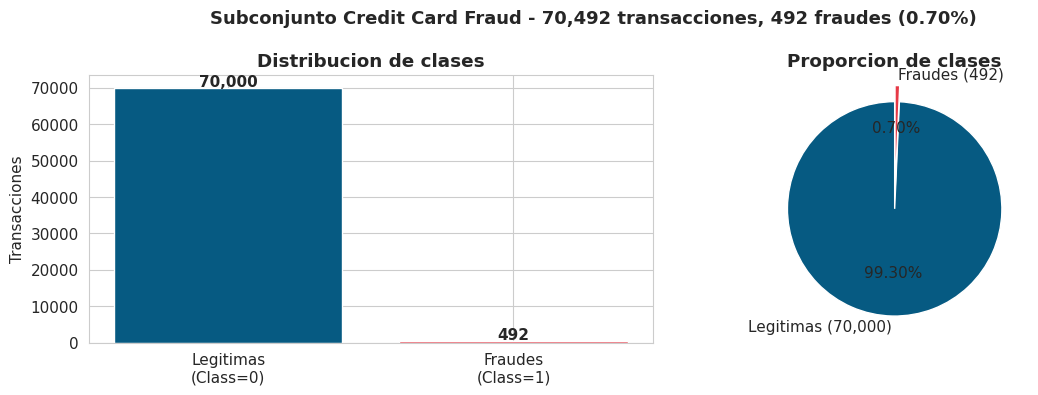

In [21]:
clase_counts = df["Class"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    ["Legitimas\n(Class=0)", "Fraudes\n(Class=1)"],
    clase_counts.values,
    color=["#065A82", "#E63946"],
)
for i, v in enumerate(clase_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Distribucion de clases", fontweight="bold")
axes[0].set_ylabel("Transacciones")

axes[1].pie(
    clase_counts.values,
    labels=[f"Legitimas ({clase_counts[0]:,})", f"Fraudes ({clase_counts[1]})"],
    colors=["#065A82", "#E63946"],
    autopct="%1.2f%%",
    startangle=90,
    explode=(0, 0.15),
)
axes[1].set_title("Proporcion de clases", fontweight="bold")

plt.suptitle(
    f"Subconjunto Credit Card Fraud - {len(df):,} transacciones, "
    f"{clase_counts[1]} fraudes ({df['Class'].mean()*100:.2f}%)",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
plt.show()

### 7.3 Distribucion de Amount por clase

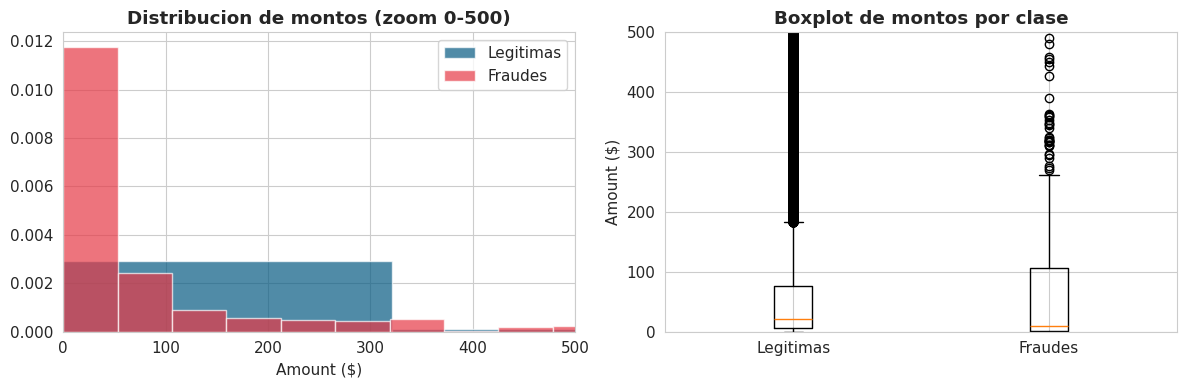

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df["Class"] == 0]["Amount"], bins=80, alpha=0.7, color="#065A82",
             label="Legitimas", density=True)
axes[0].hist(df[df["Class"] == 1]["Amount"], bins=40, alpha=0.7, color="#E63946",
             label="Fraudes", density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel("Amount ($)")
axes[0].set_title("Distribucion de montos (zoom 0-500)", fontweight="bold")
axes[0].legend()

axes[1].boxplot(
    [df[df["Class"] == 0]["Amount"], df[df["Class"] == 1]["Amount"]],
    labels=["Legitimas", "Fraudes"],
)
axes[1].set_ylabel("Amount ($)")
axes[1].set_title("Boxplot de montos por clase", fontweight="bold")
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

SECCION 8: PREPARACION DE DATOS

### 8.1 Feature engineering y split

In [23]:
from sklearn.preprocessing import RobustScaler

# Escalar Amount y Time (las unicas features no-PCA)
df["Amount_scaled"] = RobustScaler().fit_transform(df["Amount"].values.reshape(-1, 1))
df["Time_scaled"] = RobustScaler().fit_transform(df["Time"].values.reshape(-1, 1))

df_clean = df.drop(["Amount", "Time"], axis=1)

X_real = df_clean.drop("Class", axis=1).values
y_real = df_clean["Class"].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.3, random_state=RANDOM_STATE, stratify=y_real
)

pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Total": [len(y_train_r), len(y_test_r)],
    "Legitimas": [np.sum(y_train_r == 0), np.sum(y_test_r == 0)],
    "Fraudes": [np.sum(y_train_r == 1), np.sum(y_test_r == 1)],
    "% Fraude": [
        f"{np.mean(y_train_r)*100:.2f}%",
        f"{np.mean(y_test_r)*100:.2f}%",
    ],
})

,Conjunto,Total,Legitimas,Fraudes,% Fraude
0,Train,49344,49000,344,0.70%
1,Test,21148,21000,148,0.70%


SECCION 9: CASO BASE - QUE PASA SI NO SE HACE NADA?

Antes de aplicar cualquier tecnica de balanceo, es fundamental establecer
un caso base (baseline). Esto nos permite:
- Cuantificar el problema real del desbalanceo
- Medir el impacto de cada tecnica de correccion
- Evitar aplicar soluciones innecesarias si el modelo ya funciona bien

Usaremos LogisticRegression como modelo unico a lo largo de toda la Parte B,
para que las diferencias de rendimiento se deban exclusivamente a la
estrategia de balanceo, no al cambio de algoritmo.

### 9.1 Modelo baseline: Logistic Regression sin ningun balanceo

In [24]:
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc = scaler_r.transform(X_test_r)

lr_base_r = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_base_r.fit(X_train_r_sc, y_train_r)
y_pred_base_r = lr_base_r.predict(X_test_r_sc)
y_proba_base_r = lr_base_r.predict_proba(X_test_r_sc)[:, 1]

print(classification_report(y_test_r, y_pred_base_r,
                            target_names=["Legitima", "Fraude"]))

              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     21000
      Fraude       0.95      0.80      0.87       148

    accuracy                           1.00     21148
   macro avg       0.98      0.90      0.93     21148
weighted avg       1.00      1.00      1.00     21148



### 9.2 Modelo ingenuo (siempre predice "legitima")

In [25]:
y_pred_naive_r = np.zeros_like(y_test_r)

### 9.3 Comparacion visual: ingenuo vs baseline

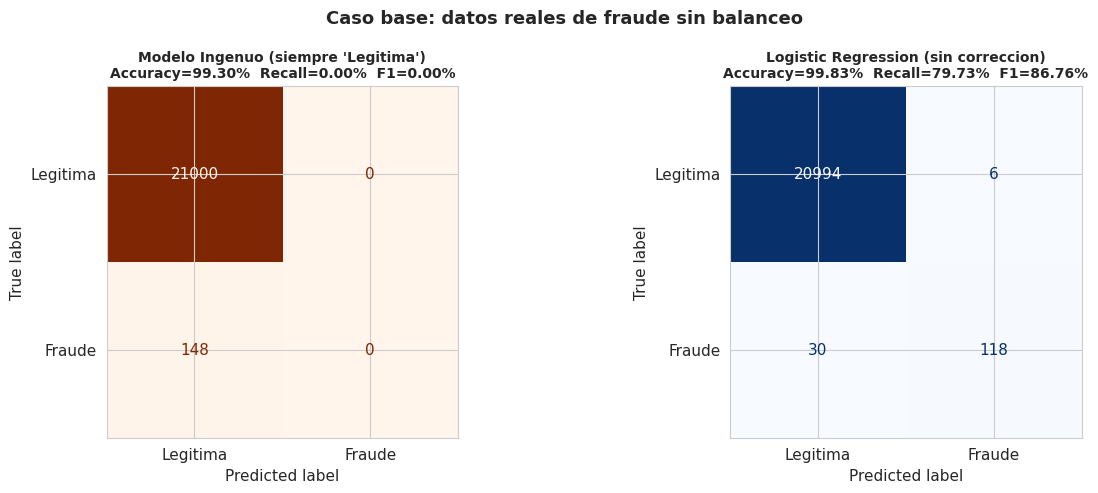

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_naive_r, ax=axes[0], cmap="Oranges", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
acc_n = accuracy_score(y_test_r, y_pred_naive_r)
rec_n = recall_score(y_test_r, y_pred_naive_r)
f1_n = f1_score(y_test_r, y_pred_naive_r)
axes[0].set_title(
    f"Modelo Ingenuo (siempre 'Legitima')\n"
    f"Accuracy={acc_n:.2%}  Recall={rec_n:.2%}  F1={f1_n:.2%}",
    fontweight="bold", fontsize=10,
)

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_base_r, ax=axes[1], cmap="Blues", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
acc_b = accuracy_score(y_test_r, y_pred_base_r)
rec_b = recall_score(y_test_r, y_pred_base_r)
f1_b = f1_score(y_test_r, y_pred_base_r)
axes[1].set_title(
    f"Logistic Regression (sin correccion)\n"
    f"Accuracy={acc_b:.2%}  Recall={rec_b:.2%}  F1={f1_b:.2%}",
    fontweight="bold", fontsize=10,
)

plt.suptitle("Caso base: datos reales de fraude sin balanceo", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# El accuracy del modelo ingenuo es altisimo (~99.3%), pero no detecta
# ningun fraude. El baseline LR detecta algunos, pero su recall muestra
# cuantos fraudes reales se le escapan.

SECCION 10: COMPARACION JUSTA - MISMO MODELO, DISTINTA ESTRATEGIA

Para aislar el efecto de cada tecnica de balanceo, usamos siempre el
MISMO algoritmo (LogisticRegression) y solo variamos la estrategia de
muestreo o ajuste de pesos. Asi cualquier mejora en las metricas se
debe exclusivamente a la tecnica de balanceo.

### 10.1 Definir todos los pipelines con Logistic Regression

In [27]:
pipelines_real = {
    "Baseline (sin correccion)": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "Solo class_weight='balanced'": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "SMOTE + class_weight": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(
            class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "Borderline-SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", BorderlineSMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "RandomUnderSampler": ImbPipeline([
        ("scaler", StandardScaler()),
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "SMOTE-Tomek": ImbPipeline([
        ("scaler", StandardScaler()),
        ("sampling", SMOTETomek(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
    "SMOTE-ENN": ImbPipeline([
        ("scaler", StandardScaler()),
        ("sampling", SMOTEENN(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]),
}

### 10.2 Evaluar cada pipeline

In [28]:
results_real = []
for name, pipe in pipelines_real.items():
    pipe.fit(X_train_r, y_train_r)
    y_pred = pipe.predict(X_test_r)
    y_proba = pipe.predict_proba(X_test_r)[:, 1]

    results_real.append({
        "Estrategia": name,
        "Accuracy": accuracy_score(y_test_r, y_pred),
        "Precision": precision_score(y_test_r, y_pred),
        "Recall": recall_score(y_test_r, y_pred),
        "F1": f1_score(y_test_r, y_pred),
        "AUC-PR": average_precision_score(y_test_r, y_proba),
    })

df_real = pd.DataFrame(results_real)
df_real.round(4)

,Estrategia,Accuracy,Precision,Recall,F1,AUC-PR
0,Baseline (sin correccion),0.9983,0.9516,0.7973,0.8676,0.8508
1,Solo class_weight='balanced',0.9758,0.2114,0.8986,0.3423,0.8507
2,SMOTE,0.9747,0.2040,0.8986,0.3325,0.8485
3,SMOTE + class_weight,0.9747,0.2040,0.8986,0.3325,0.8485
4,Borderline-SMOTE,0.9858,0.3137,0.8649,0.4604,0.8309
5,RandomUnderSampler,0.9751,0.2044,0.8851,0.3321,0.8271
6,SMOTE-Tomek,0.9747,0.2040,0.8986,0.3325,0.8485
7,SMOTE-ENN,0.9713,0.1846,0.9054,0.3066,0.8248


### 10.3 Visualizacion: comparacion de metricas

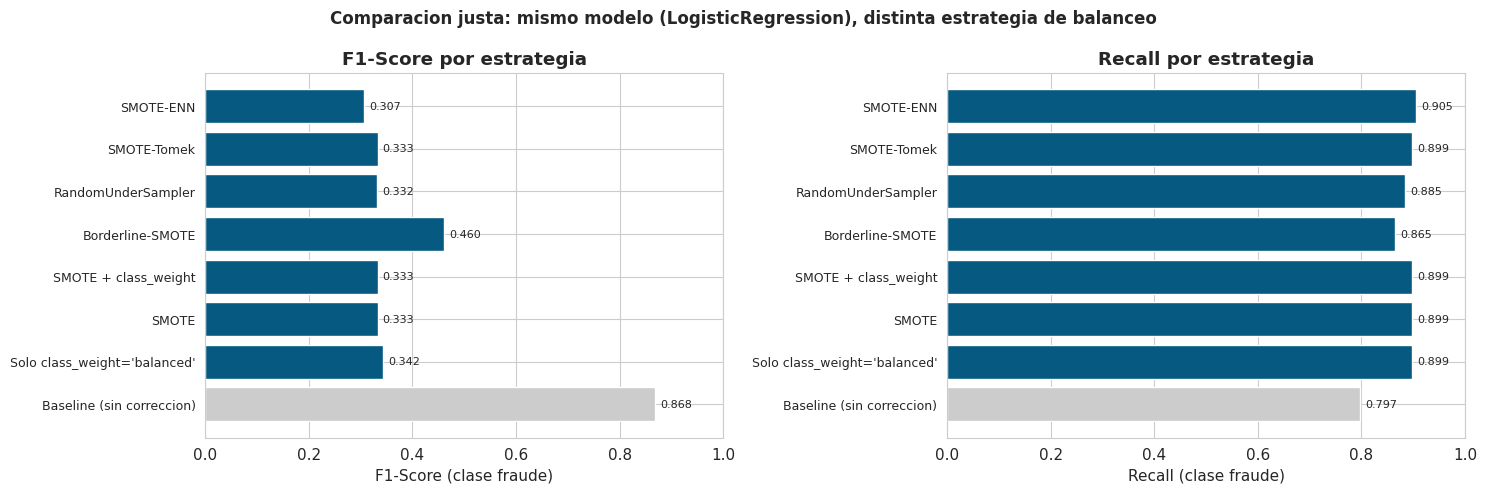

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1-Score
nombres = df_real["Estrategia"]
y_pos = np.arange(len(nombres))
colores_f1 = ["#999999"] + ["#065A82"] * (len(nombres) - 1)  # gris para baseline
colores_f1[0] = "#CCCCCC"  # baseline mas claro

bars = axes[0].barh(y_pos, df_real["F1"], color=colores_f1, edgecolor="white")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(nombres, fontsize=9)
axes[0].set_xlabel("F1-Score (clase fraude)")
axes[0].set_title("F1-Score por estrategia", fontweight="bold")
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, df_real["F1"]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8)

# Recall
bars2 = axes[1].barh(y_pos, df_real["Recall"], color=colores_f1, edgecolor="white")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(nombres, fontsize=9)
axes[1].set_xlabel("Recall (clase fraude)")
axes[1].set_title("Recall por estrategia", fontweight="bold")
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, df_real["Recall"]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8)

plt.suptitle(
    "Comparacion justa: mismo modelo (LogisticRegression), distinta estrategia de balanceo",
    fontweight="bold", fontsize=12,
)
plt.tight_layout()
plt.show()

### 10.4 Matrices de confusion: baseline vs mejor estrategia

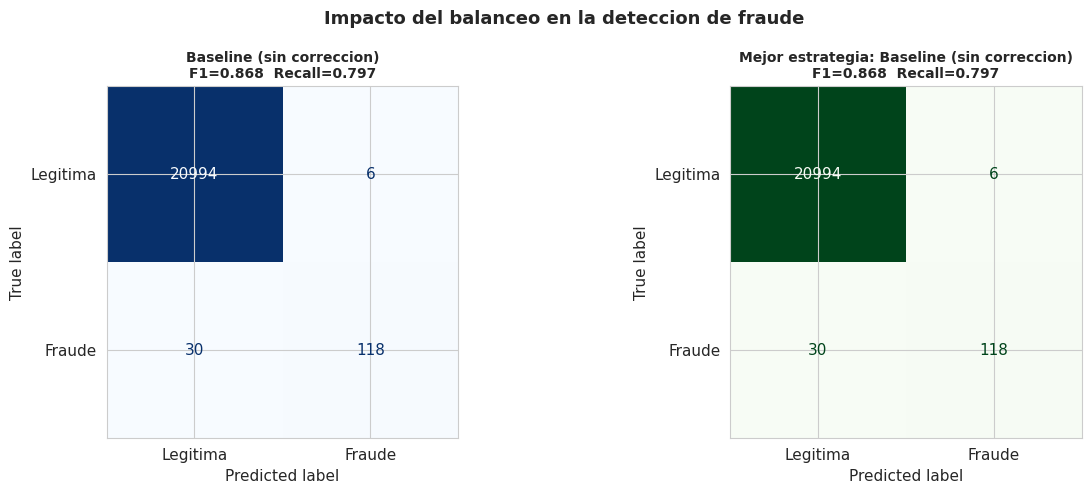

In [30]:
best_name = df_real.loc[df_real["F1"].idxmax(), "Estrategia"]
best_pipe = pipelines_real[best_name]
best_pipe.fit(X_train_r, y_train_r)
y_pred_best = best_pipe.predict(X_test_r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_base_r, ax=axes[0], cmap="Blues", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
axes[0].set_title(
    f"Baseline (sin correccion)\n"
    f"F1={f1_score(y_test_r, y_pred_base_r):.3f}  "
    f"Recall={recall_score(y_test_r, y_pred_base_r):.3f}",
    fontweight="bold", fontsize=10,
)

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_best, ax=axes[1], cmap="Greens", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
axes[1].set_title(
    f"Mejor estrategia: {best_name}\n"
    f"F1={f1_score(y_test_r, y_pred_best):.3f}  "
    f"Recall={recall_score(y_test_r, y_pred_best):.3f}",
    fontweight="bold", fontsize=10,
)

plt.suptitle("Impacto del balanceo en la deteccion de fraude", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

SECCION 11: THRESHOLD TUNING CON DATOS REALES

### 11.1 Optimizar el threshold sobre la mejor estrategia

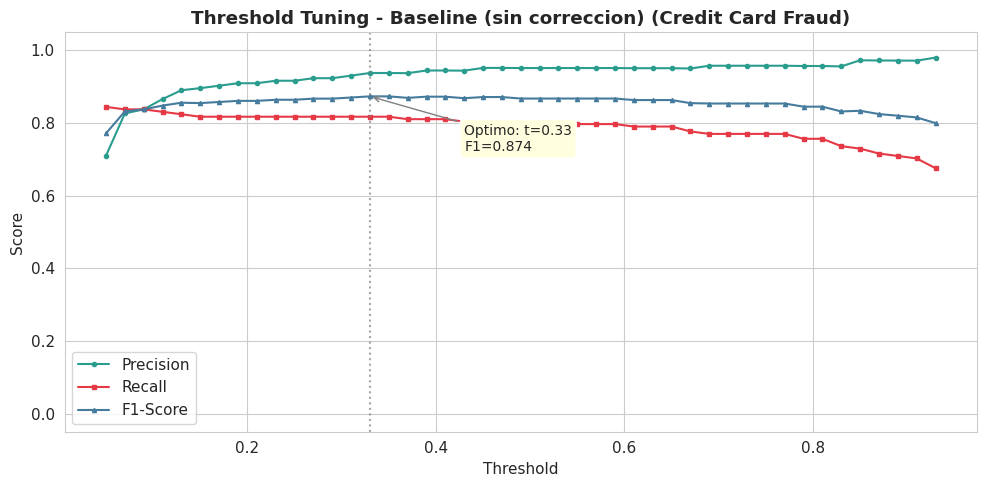

In [31]:
y_proba_best_r = best_pipe.predict_proba(X_test_r)[:, 1]

thresholds_r = np.arange(0.05, 0.95, 0.02)
metrics_real_t = []
for t in thresholds_r:
    y_pred_t = (y_proba_best_r >= t).astype(int)
    metrics_real_t.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test_r, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test_r, y_pred_t),
        "F1": f1_score(y_test_r, y_pred_t, zero_division=0),
    })

df_t_r = pd.DataFrame(metrics_real_t)
best_idx_r = df_t_r["F1"].idxmax()
best_t_r = df_t_r.loc[best_idx_r, "Threshold"]
best_f1_r = df_t_r.loc[best_idx_r, "F1"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t_r["Threshold"], df_t_r["Precision"], "o-", color="#2A9D8F", label="Precision", ms=3)
ax.plot(df_t_r["Threshold"], df_t_r["Recall"], "s-", color="#E63946", label="Recall", ms=3)
ax.plot(df_t_r["Threshold"], df_t_r["F1"], "^-", color="#457B9D", label="F1-Score", ms=3)
ax.axvline(x=best_t_r, color="gray", linestyle=":", alpha=0.7)
ax.annotate(f"Optimo: t={best_t_r}\nF1={best_f1_r:.3f}", xy=(best_t_r, best_f1_r),
            xytext=(best_t_r + 0.1, best_f1_r - 0.15),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Tuning - {best_name} (Credit Card Fraud)", fontweight="bold")
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### 11.2 Comparacion: default vs threshold optimizado

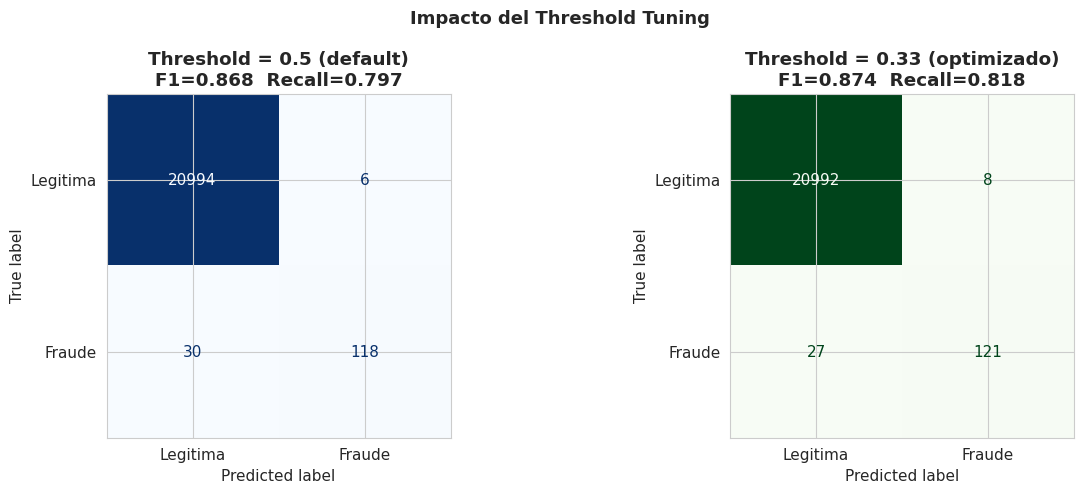

In [32]:
y_pred_default = best_pipe.predict(X_test_r)  # threshold 0.5
y_pred_opt = (y_proba_best_r >= best_t_r).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_default, ax=axes[0], cmap="Blues", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
axes[0].set_title(
    f"Threshold = 0.5 (default)\n"
    f"F1={f1_score(y_test_r, y_pred_default):.3f}  "
    f"Recall={recall_score(y_test_r, y_pred_default):.3f}",
    fontweight="bold",
)

ConfusionMatrixDisplay.from_predictions(
    y_test_r, y_pred_opt, ax=axes[1], cmap="Greens", colorbar=False,
    display_labels=["Legitima", "Fraude"],
)
axes[1].set_title(
    f"Threshold = {best_t_r} (optimizado)\n"
    f"F1={f1_score(y_test_r, y_pred_opt):.3f}  "
    f"Recall={recall_score(y_test_r, y_pred_opt):.3f}",
    fontweight="bold",
)

plt.suptitle("Impacto del Threshold Tuning", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 11.3 Analisis de costo con datos reales

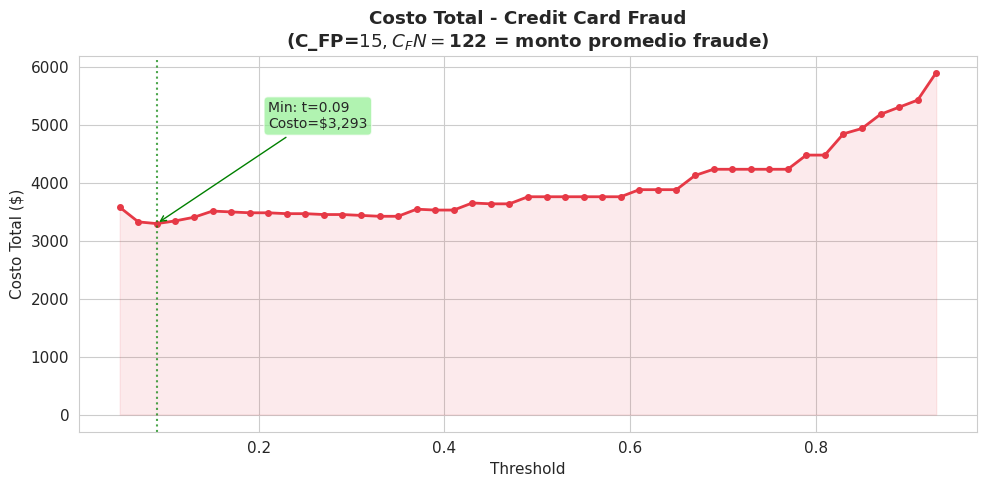

,Metrica,Valor
0,Threshold optimo (costo),0.09
1,Fraudes detectados,124
2,Fraudes perdidos,24
3,Falsas alarmas,24
4,Costo total ($),"$3,293"


In [33]:
monto_fraude_promedio = df[df["Class"] == 1]["Amount"].mean()
C_FP_real = 15
C_FN_real = monto_fraude_promedio

costos_r = []
for t in thresholds_r:
    y_pred_t = (y_proba_best_r >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_r, y_pred_t).ravel()
    costos_r.append({
        "Threshold": round(t, 2),
        "Fraudes_detectados": tp,
        "Fraudes_perdidos": fn,
        "Falsas_alarmas": fp,
        "Costo_total": fp * C_FP_real + fn * C_FN_real,
    })

df_costos_r = pd.DataFrame(costos_r)
min_cost_idx = df_costos_r["Costo_total"].idxmin()
min_t_r = df_costos_r.loc[min_cost_idx, "Threshold"]
min_c_r = df_costos_r.loc[min_cost_idx, "Costo_total"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_costos_r["Threshold"], df_costos_r["Costo_total"],
        "o-", color="#E63946", lw=2, ms=4)
ax.fill_between(df_costos_r["Threshold"], df_costos_r["Costo_total"],
                alpha=0.1, color="#E63946")
ax.axvline(x=min_t_r, color="green", linestyle=":", alpha=0.7)
ax.annotate(f"Min: t={min_t_r}\nCosto=${min_c_r:,.0f}", xy=(min_t_r, min_c_r),
            xytext=(min_t_r + 0.12, min_c_r * 1.5),
            arrowprops=dict(arrowstyle="->", color="green"), fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
ax.set_xlabel("Threshold")
ax.set_ylabel("Costo Total ($)")
ax.set_title(
    f"Costo Total - Credit Card Fraud\n"
    f"(C_FP=${C_FP_real}, C_FN=${monto_fraude_promedio:.0f} = monto promedio fraude)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

row_min = df_costos_r.loc[min_cost_idx]
pd.DataFrame({
    "Metrica": [
        "Threshold optimo (costo)", "Fraudes detectados",
        "Fraudes perdidos", "Falsas alarmas", "Costo total ($)",
    ],
    "Valor": [
        row_min["Threshold"], int(row_min["Fraudes_detectados"]),
        int(row_min["Fraudes_perdidos"]), int(row_min["Falsas_alarmas"]),
        f"${row_min['Costo_total']:,.0f}",
    ],
})

SECCION 12: CURVAS PR Y ROC COMPARATIVAS

### 12.1 Curvas para las principales estrategias (mismo modelo LR)

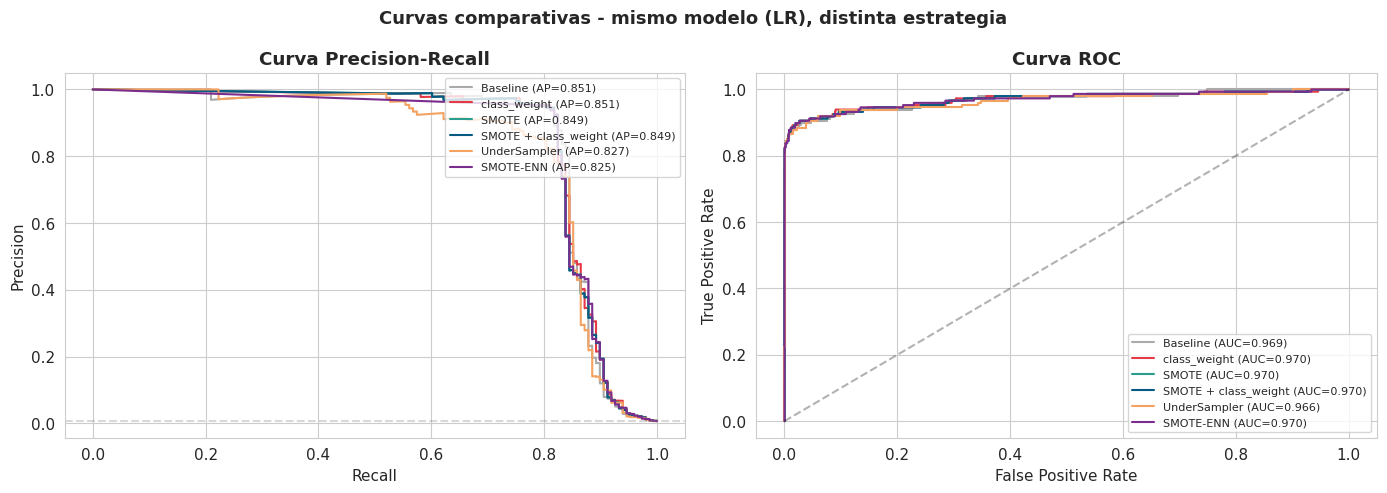

In [34]:
from sklearn.metrics import roc_curve as roc_curve_fn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

estrategias_curvas = {
    "Baseline": "Baseline (sin correccion)",
    "class_weight": "Solo class_weight='balanced'",
    "SMOTE": "SMOTE",
    "SMOTE + class_weight": "SMOTE + class_weight",
    "UnderSampler": "RandomUnderSampler",
    "SMOTE-ENN": "SMOTE-ENN",
}
colores_curvas = ["#AAAAAA", "#E63946", "#2A9D8F", "#065A82", "#F4A261", "#7B2D8E"]

for (label, pipe_name), color in zip(estrategias_curvas.items(), colores_curvas):
    pipe = pipelines_real[pipe_name]
    pipe.fit(X_train_r, y_train_r)
    y_proba_c = pipe.predict_proba(X_test_r)[:, 1]

    prec_c, rec_c, _ = precision_recall_curve(y_test_r, y_proba_c)
    ap_c = average_precision_score(y_test_r, y_proba_c)
    axes[0].plot(rec_c, prec_c, color=color, lw=1.5, label=f"{label} (AP={ap_c:.3f})")

    fpr, tpr, _ = roc_curve_fn(y_test_r, y_proba_c)
    auc_c = roc_auc_score(y_test_r, y_proba_c)
    axes[1].plot(fpr, tpr, color=color, lw=1.5, label=f"{label} (AUC={auc_c:.3f})")

baseline_prop = y_test_r.sum() / len(y_test_r)
axes[0].axhline(y=baseline_prop, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend(fontsize=8, loc="lower right")

plt.suptitle(
    "Curvas comparativas - mismo modelo (LR), distinta estrategia",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
plt.show()

RESUMEN Y RECOMENDACIONES

1. Siempre analizar el balance de clases antes de modelar.

2. No confiar en accuracy con datos desbalanceados. Usar F1, AUC-PR o
 metricas alineadas con el costo de negocio.

3. SMOTE solo en entrenamiento. Nunca antes del split. Usar ImbPipeline
 para evitar data leakage automaticamente.

4. Combinar estrategias: SMOTE + class_weight + threshold tuning suelen
 ser mas efectivos juntos que por separado.

5. Validar con cross-validation estratificado (StratifiedKFold).

6. El threshold de 0.5 casi nunca es optimo. Evaluar diferentes thresholds
 usando precision_recall_curve() y el costo de negocio.

7. El mejor modelo no es el mas preciso segun F1, sino el que minimiza
 el costo total de errores en el contexto real.